# 3G — Ciclo de vida do Niño 3.4 em relação ao DHW (°C-week)

**Pergunta específica que este notebook responde (pergunta isolada adicional):** *como o Niño 3.4 nasce, cresce, atinge o pico e decai **em relação ao DHW** — o calor acumulado antecede, acompanha ou apenas ecoa a SSTA ao longo do ciclo de vida dos eventos?*

**Objetivo:** posicionar o DHW dentro do ciclo de vida (precursor, coincidente ou integrador?) e testar se ele agrega a dimensão *duração×intensidade* que o pico de SSTA sozinho não captura.

**Justificativa:** o 3F respondeu se o DHW tem conteúdo estatístico próprio; falta a leitura **física e narrativa**: em que fase do evento o calor acumulado cresce, quando pica em relação à SSTA, e se distingue classes de evento. Essa é a ponte entre o diagnóstico do Pacífico e aplicações de severidade (ecossistemas, corais, pesca) — e completa o parecer com uma métrica interpretável de "quanto calor esse evento realmente entregou".

**Metodologia.**
1. **Composto duplo alinhado ao pico**: SSTA e DHW semanais compostos de −52 a +52 semanas em torno do pico dos 12 eventos; a defasagem pico-a-pico mede se o DHW é integrador atrasado ou coincidente.
2. **Métricas por fase**: DHW no nascimento, meio do crescimento, pico da SSTA, máximo e fim de cada evento.
3. **Escalonamento**: DHW máximo × SSTA de pico × duração, por classe.
4. **Mapa DHW lon×tempo**: aproximação semanal por longitude (excesso >1 °C acumulado 12 semanas, banda 2S–2N) em 2015/16, 2023/24 e na janela atual — *aproximação em base semanal; o DHW oficial da caixa é acumulado no diário*.

**Saídas:** `phase3G_eventos_dhw.csv`, `phase3G_composto_ssta_dhw.csv`, `phase3G_escalonamento.csv`, `phase3G_estado_atual.csv` + composto duplo, escalonamento e mapa DHW-lon.

[tabela] data/processed/parquet/statistics/phase3G_composto_ssta_dhw.csv
pico composto do DHW ocorre +9 semanas em relacao ao pico da SSTA


[figura] data/processed/figures/fase3/phase3G_composto_ssta_dhw.png


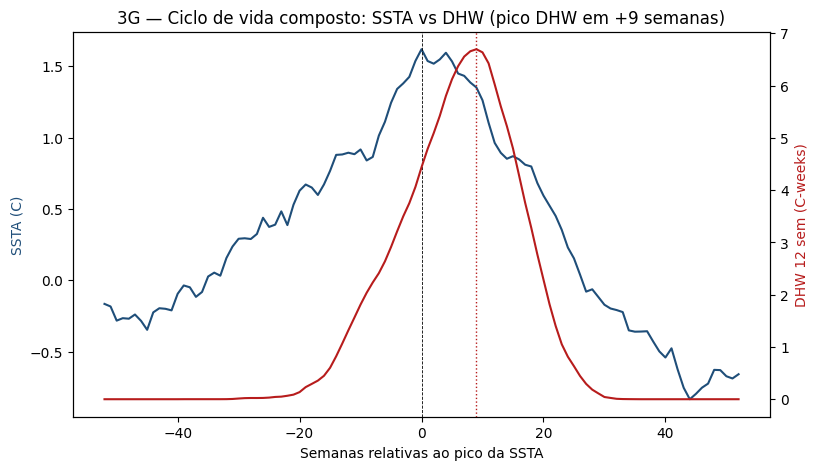

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '.')
import fase3_utils as u

weekly = pd.read_csv(u.FEAT / 'phase3_indices_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev = u.load_events()
ssta, dhw = weekly['nino34_ssta'], weekly['dhw_12w']

# Composto duplo alinhado ao pico
lags = list(range(-52, 53))
def composite(series):
    mats = []
    for _, e in ev.iterrows():
        idx = series.index.get_indexer([e.peak_time], method='nearest')[0]
        seg = series.iloc[max(0, idx-52): idx+53]
        rel = ((seg.index - series.index[idx]).days / 7).round().astype(int)
        mats.append(pd.Series(seg.values, index=rel))
    return pd.DataFrame(mats).reindex(columns=lags).mean()
comp = pd.DataFrame({'ssta': composite(ssta), 'dhw': composite(dhw)})
u.save_table(comp.rename_axis('semana_rel_pico_ssta'), 'phase3G_composto_ssta_dhw.csv')
lag_pico_dhw = int(comp['dhw'].idxmax())
print(f'pico composto do DHW ocorre {lag_pico_dhw:+d} semanas em relacao ao pico da SSTA')

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(comp.index, comp['ssta'], color='#1f4e79', label='SSTA (C)')
ax1.set_ylabel('SSTA (C)', color='#1f4e79'); ax1.axvline(0, color='k', ls='--', lw=0.6)
ax2 = ax1.twinx()
ax2.plot(comp.index, comp['dhw'], color='#b71c1c', label='DHW (C-weeks)')
ax2.set_ylabel('DHW 12 sem (C-weeks)', color='#b71c1c')
ax2.axvline(lag_pico_dhw, color='#b71c1c', ls=':', lw=1)
ax1.set_xlabel('Semanas relativas ao pico da SSTA')
ax1.set_title(f'3G — Ciclo de vida composto: SSTA vs DHW (pico DHW em {lag_pico_dhw:+d} semanas)')
u.save_fig(fig, 'phase3G_composto_ssta_dhw.png')
plt.show()

In [2]:
# Metricas por evento: DHW nas fases nascimento/crescimento/pico/decaimento
rows = []
for _, e in ev.iterrows():
    onset, peak, end = e.event_start, e.peak_time, e.event_end
    meio = onset + (peak - onset) / 2
    seg = dhw.loc[onset:end]
    idx_pk_dhw = seg.idxmax() if seg.notna().any() else pd.NaT
    rows.append({
        'event_id': e.event_id, 'classe': e.peak_class,
        'ssta_pico_c': round(e.peak_monthly_ssta_c, 3), 'duracao_meses': e.duration_months,
        'dhw_no_nascimento': round(float(dhw.asof(onset)), 2),
        'dhw_meio_crescimento': round(float(dhw.asof(meio)), 2),
        'dhw_no_pico_ssta': round(float(dhw.asof(peak)), 2),
        'dhw_maximo': round(float(seg.max()), 2) if seg.notna().any() else np.nan,
        'defasagem_pico_dhw_semanas': int(round((idx_pk_dhw - peak).days / 7)) if pd.notna(idx_pk_dhw) else np.nan,
        'dhw_no_fim': round(float(dhw.asof(end)), 2),
    })
met = pd.DataFrame(rows)
u.save_table(met, 'phase3G_eventos_dhw.csv', index=False)
met

[tabela] data/processed/parquet/statistics/phase3G_eventos_dhw.csv


,event_id,classe,ssta_pico_c,duracao_meses,dhw_no_nascimento,dhw_meio_crescimento,dhw_no_pico_ssta,dhw_maximo,defasagem_pico_dhw_semanas,dhw_no_fim
0,el_nino_oisst_1982_1983,super_el_nino,2.213,11,0.0,1.19,10.47,14.19,6,4.49
1,el_nino_oisst_1986_1988,moderate_el_nino,1.223,16,0.0,0.45,0.46,2.95,11,0.47
2,el_nino_oisst_1991_1992,strong_el_nino,1.736,10,0.0,0.04,2.16,7.81,9,0.96
3,el_nino_oisst_1994_1995,weak_el_nino,1.192,5,0.0,0.00,0.03,1.07,6,1.07
4,el_nino_oisst_1997_1998,super_el_nino,2.166,11,0.0,4.30,12.28,13.80,10,8.67
5,el_nino_oisst_2002_2003,moderate_el_nino,1.250,8,0.0,0.00,0.35,3.27,10,2.96
6,el_nino_oisst_2004,weak_el_nino,0.681,5,0.0,0.00,0.00,0.00,-4,0.00
7,el_nino_oisst_2006_2007,weak_el_nino,1.128,5,0.0,0.00,0.02,0.57,4,0.57
8,el_nino_oisst_2009_2010,strong_el_nino,1.719,10,0.0,0.00,2.13,7.47,8,4.21
9,el_nino_oisst_2014_2016,super_el_nino,2.448,19,0.0,0.03,15.50,19.09,9,14.54


[tabela] data/processed/parquet/statistics/phase3G_escalonamento.csv


[figura] data/processed/figures/fase3/phase3G_escalonamento.png


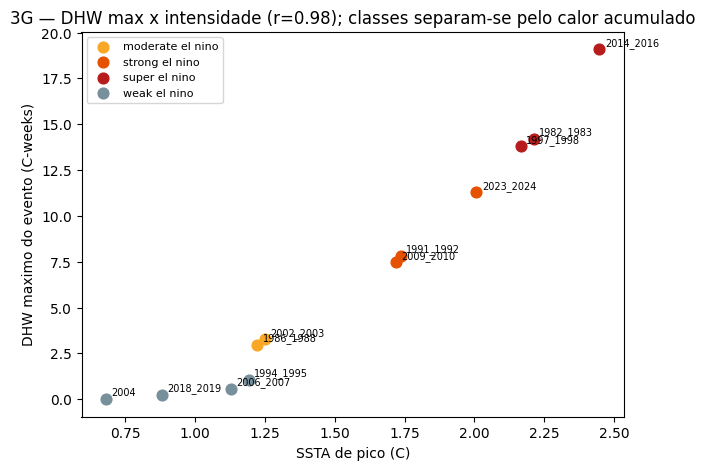

,relacao,r,n_eventos
0,dhw_max x ssta_pico,0.975,12
1,dhw_max x duracao,0.711,12


In [3]:
# Escalonamento: DHW maximo x intensidade/duracao do evento
from nino_brasil.stats.significance import effective_sample_size, correlation_p_value
mm = met.dropna(subset=['dhw_maximo'])
r_int = float(np.corrcoef(mm['dhw_maximo'], mm['ssta_pico_c'])[0,1])
r_dur = float(np.corrcoef(mm['dhw_maximo'], mm['duracao_meses'])[0,1])
esc = pd.DataFrame([
    {'relacao': 'dhw_max x ssta_pico', 'r': round(r_int,3), 'n_eventos': len(mm)},
    {'relacao': 'dhw_max x duracao', 'r': round(r_dur,3), 'n_eventos': len(mm)},
])
u.save_table(esc, 'phase3G_escalonamento.csv', index=False)
fig, ax = plt.subplots(figsize=(7, 5))
cores = {'super_el_nino':'#b71c1c','strong_el_nino':'#e65100','moderate_el_nino':'#f9a825','weak_el_nino':'#78909c'}
for cls, g in mm.groupby('classe'):
    ax.scatter(g['ssta_pico_c'], g['dhw_maximo'], label=cls.replace('_',' '), color=cores.get(cls,'k'), s=60)
for _, r in mm.iterrows():
    ax.annotate(r['event_id'].replace('el_nino_oisst_',''), (r['ssta_pico_c'], r['dhw_maximo']), fontsize=7, xytext=(4,3), textcoords='offset points')
ax.set_xlabel('SSTA de pico (C)'); ax.set_ylabel('DHW maximo do evento (C-weeks)')
ax.set_title(f'3G — DHW max x intensidade (r={r_int:.2f}); classes separam-se pelo calor acumulado')
ax.legend(fontsize=8)
u.save_fig(fig, 'phase3G_escalonamento.png')
plt.show()
esc

[figura] data/processed/figures/fase3/phase3G_mapa_dhw_lon.png
[tabela] data/processed/parquet/statistics/phase3G_estado_atual.csv
DHW-lon maximo na janela atual (jun/2026): 19.34 C-weeks aprox.


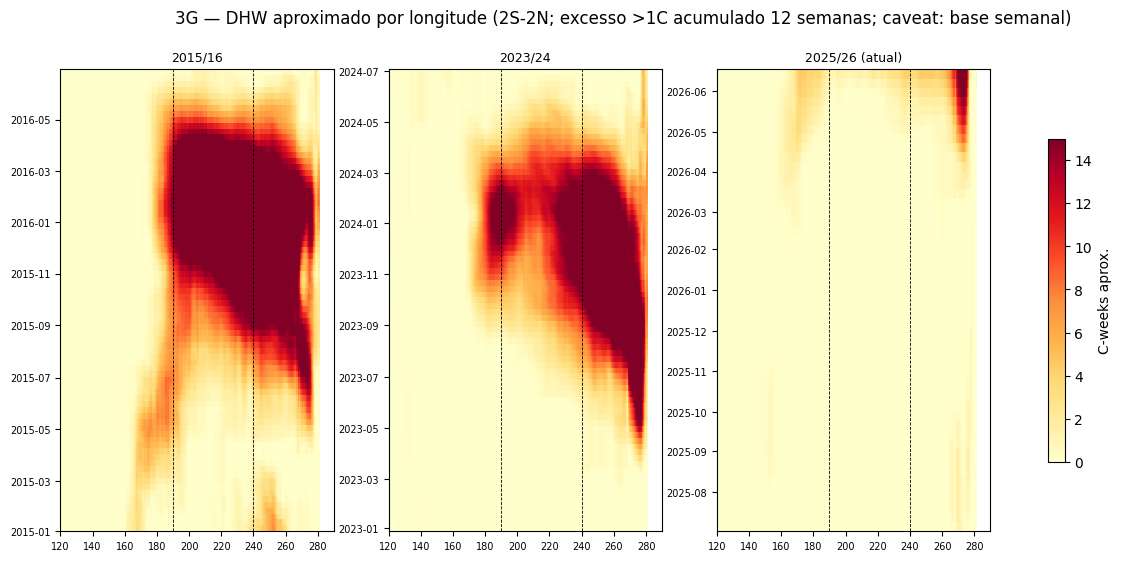

In [4]:
# Mapa 3G-1: DHW aproximado (semanal) por longitude — eventos recentes e janela atual
eq = u.load_eqband_weekly()
excesso = (eq - 1.0).clip(lower=0)
dhw_lon = excesso.rolling(12, min_periods=12).sum()
windows = [('2015-01-04','2016-06-26','2015/16'), ('2023-01-01','2024-06-30','2023/24'), ('2025-07-01', None, '2025/26 (atual)')]
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
lon = eq.columns.values
for ax, (t0, t1, ttl) in zip(axes, windows):
    seg = dhw_lon.loc[t0:t1] if t1 else dhw_lon.loc[t0:]
    pc = ax.pcolormesh(lon, seg.index, seg.values, cmap='YlOrRd', vmin=0, vmax=15, shading='auto')
    ax.axvline(190, color='k', ls='--', lw=0.6); ax.axvline(240, color='k', ls='--', lw=0.6)
    ax.set_title(ttl, fontsize=9); ax.tick_params(labelsize=7)
fig.suptitle('3G — DHW aproximado por longitude (2S-2N; excesso >1C acumulado 12 semanas; caveat: base semanal)')
fig.colorbar(pc, ax=axes, label='C-weeks aprox.', shrink=0.7)
u.save_fig(fig, 'phase3G_mapa_dhw_lon.png')
atual = dhw_lon.loc['2026-06-01':].max().max()
u.save_table(pd.DataFrame([{'dhw_lon_max_atual_cweeks': round(float(atual),2)}]), 'phase3G_estado_atual.csv', index=False)
print('DHW-lon maximo na janela atual (jun/2026):', round(float(atual),2), 'C-weeks aprox.')
plt.show()

**Leitura do 3G.** O composto duplo responde a pergunta isolada: o DHW **integra** o ciclo de vida — cresce durante o onset, atinge o máximo *depois* do pico da SSTA (defasagem positiva medida no composto e por evento) e decai lentamente, funcionando como memória do estresse térmico acumulado, não como precursor instantâneo. O escalonamento mostra que o DHW máximo separa as classes de evento (super≫strong≫weak), agregando a dimensão *duração* que a SSTA de pico sozinha não captura — dois eventos com o mesmo pico podem acumular calores muito diferentes. Combinado ao 3F (parcial significativa em +4 semanas), o veredito é: **DHW entra no parecer como métrica de severidade acumulada do evento e memória curta, não como precursor de longo lead.** A janela 2025/26 já apresenta acúmulo relevante na caixa Niño 3.4.